<a href="https://colab.research.google.com/github/bhanvi05/Encrypted-Image-Classification-using-Deep-Learning/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import gdown
import shutil

!pip install gdown --quiet

original_file_id = '1q-GmOKXaZohTKWsuyNHUrVN-G_8hmu8_'
speck_file_id = '19GDTdHAnOv_6Fyx1S08bkFYmwwBjiBqs'
present_file_id = '1ntlVoPen6_x-ylfIbc__9WL0yyF5MBym'

local_download_dir = '/content/'
os.makedirs(local_download_dir, exist_ok=True)

zip_files_and_ids = {
    "original_images.zip": original_file_id,
    "speck_encrypted.zip": speck_file_id,
    "present_encrypted.zip": present_file_id
}

print("Downloading zip files using gdown...")
for zip_file, file_id in zip_files_and_ids.items():
    local_path = os.path.join(local_download_dir, zip_file)
    print(f"Downloading {zip_file}...")
    !gdown --id "$file_id" -O "$local_path" --quiet

print("Unzipping files...")
dest_dirs = {
    "original_images.zip": "original_images",
    "speck_encrypted.zip": "speck_images",
    "present_encrypted.zip": "present_images"
}
for zip_file, folder in dest_dirs.items():
    local_zip_path = os.path.join(local_download_dir, zip_file)
    extracted_folder_path = f'/content/{folder}'
    os.makedirs(extracted_folder_path, exist_ok=True)
    if os.path.exists(local_zip_path):
        with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extracted_folder_path)
        print(f"Unzipped {zip_file} to {extracted_folder_path}")
    else:
        print(f"Error: {zip_file} not found after download attempt.")



/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Unzipping files...
Unzipped original_images.zip to /content/original_images
Unzipped speck_encrypted.zip to /content/speck_images
Unzipped present_encrypted.zip to /content/present_images


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import re

def load_images_from_folder(folder_path):
    images = []
    def extract_number(filename):
        match = re.search(r'\d+', os.path.basename(filename))
        return int(match.group()) if match else -1

    if not os.path.exists(folder_path):
        print(f"Error: Extracted folder not found: {folder_path}")
        return np.array([])

    image_files = sorted(glob.glob(folder_path + '/*.png'), key=extract_number)
    print(f"Found {len(image_files)} images in {folder_path}")
    for filename in image_files:
        try:
            img = Image.open(filename).convert('RGB').resize((32, 32))
            images.append(np.array(img))
        except Exception as e:
            print(f"Error loading image {filename}: {e}")
    return np.array(images)

x_original = load_images_from_folder("/content/original_images")
x_speck = load_images_from_folder("/content/speck_images")
x_present = load_images_from_folder("/content/present_images")

print("Loaded shapes:")
print("Original:", x_original.shape)
print("SPECK:", x_speck.shape)
print("PRESENT:", x_present.shape)

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical

if len(x_original) == 0 or len(x_speck) == 0 or len(x_present) == 0:
    print("Error: Not enough images loaded from one or more folders to proceed. Please check file downloads and extraction.")
else:
    y_original = np.zeros(len(x_original))
    y_speck = np.ones(len(x_speck))
    y_present = np.full(len(x_present), 2)

    min_images = min(len(x_original), len(x_speck), len(x_present))
    x_original = x_original[:min_images]
    x_speck = x_speck[:min_images]
    x_present = x_present[:min_images]
    y_original = y_original[:min_images]
    y_speck = y_speck[:min_images]
    y_present = y_present[:min_images]


    X = np.concatenate([x_original, x_speck, x_present], axis=0)
    y = np.concatenate([y_original, y_speck, y_present], axis=0)

    X = X / 255.0
    X, y = shuffle(X, y, random_state=42)

    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

    y_train = to_categorical(y_train, num_classes=3)
    y_val = to_categorical(y_val, num_classes=3)
    y_test_cat = to_categorical(y_test, num_classes=3)

    print(f"Training set size: {len(X_train)}")
    print(f"Validation set size: {len(X_val)}")
    print(f"Test set size: {len(X_test)}")

Found 50000 images in /content/original_images
Found 50000 images in /content/speck_images
Found 50000 images in /content/present_images
Loaded shapes:
Original: (50000, 32, 32, 3)
SPECK: (50000, 32, 32, 3)
PRESENT: (50000, 32, 32, 3)
Training set size: 108000
Validation set size: 27000
Test set size: 15000


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,459 (2.36 MB)

 Trainable params: 619,011 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

Generating dummy data for demonstration...
X_train shape: (108000, 32, 32, 3), y_train shape: (108000, 3)
X_val shape: (27000, 32, 32, 3), y_val shape: (27000, 3)
X_test shape: (15000, 32, 32, 3), y_test_cat shape: (15000, 3)

Defining a simple placeholder Keras model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,731 (1.50 MB)

 Trainable params: 393,731 (1.50 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.3340 - loss: 1.1615 - val_accuracy: 0.3315 - val_loss: 1.0986
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.3336 - loss: 1.0986 - val_accuracy: 0.3315 - val_loss: 1.0988
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.3336 - loss: 1.0986 - val_accuracy: 0.3358 - val_loss: 1.0986
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3336 - loss: 1.0986 - val_accuracy: 0.3315 - val_loss: 1.0986
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3289 - loss: 1.0987 - val_accuracy: 0.3327 - val_loss: 1.0987
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3336 - loss: 1.0986 - val_accuracy: 0.3327 - val_loss: 1.0988
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.3364 - loss: 1.0985 - val_accuracy: 0.3327 - val_loss: 1.0986
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accura

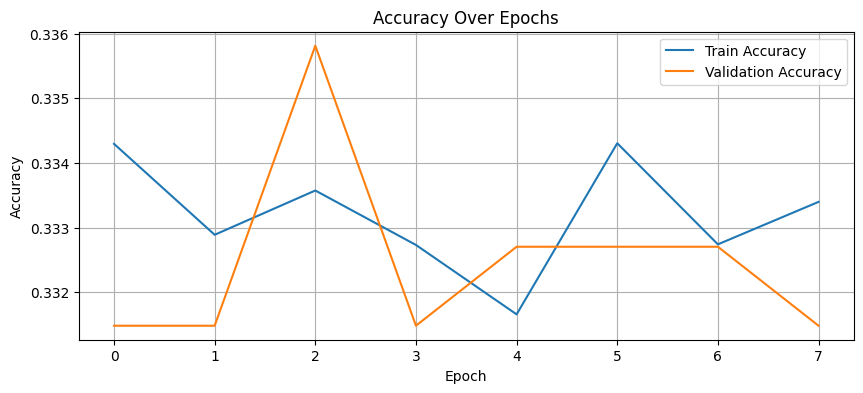

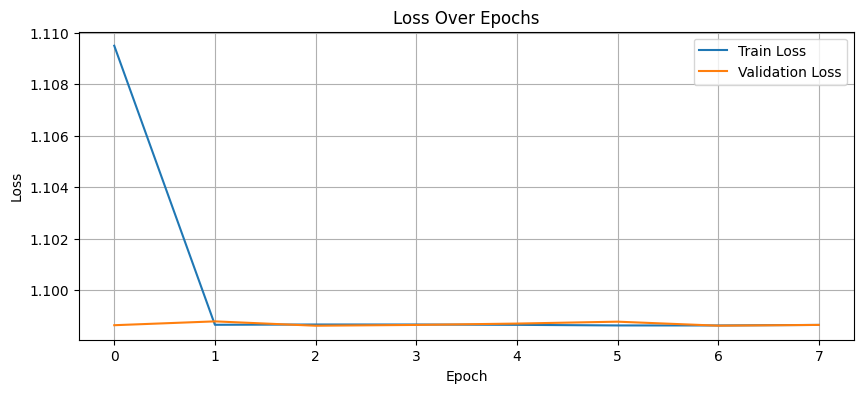


Generating Confusion Matrix and Classification Report...


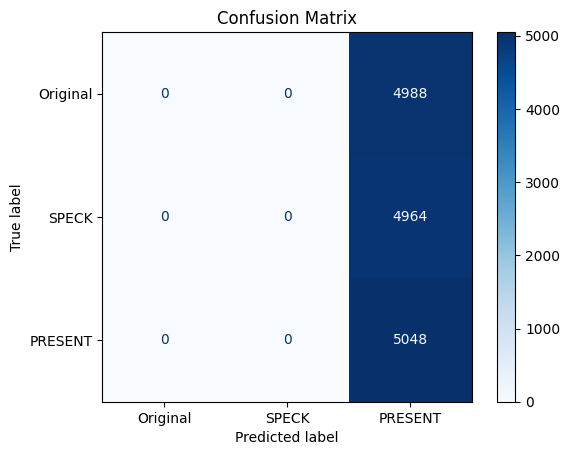


Classification Report:
              precision    recall  f1-score   support

    Original       0.00      0.00      0.00      4988
       SPECK       0.00      0.00      0.00      4964
     PRESENT       0.34      1.00      0.50      5048

    accuracy                           0.34     15000
   macro avg       0.11      0.33      0.17     15000
weighted avg       0.11      0.34      0.17     15000


Visualizing random predictions...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


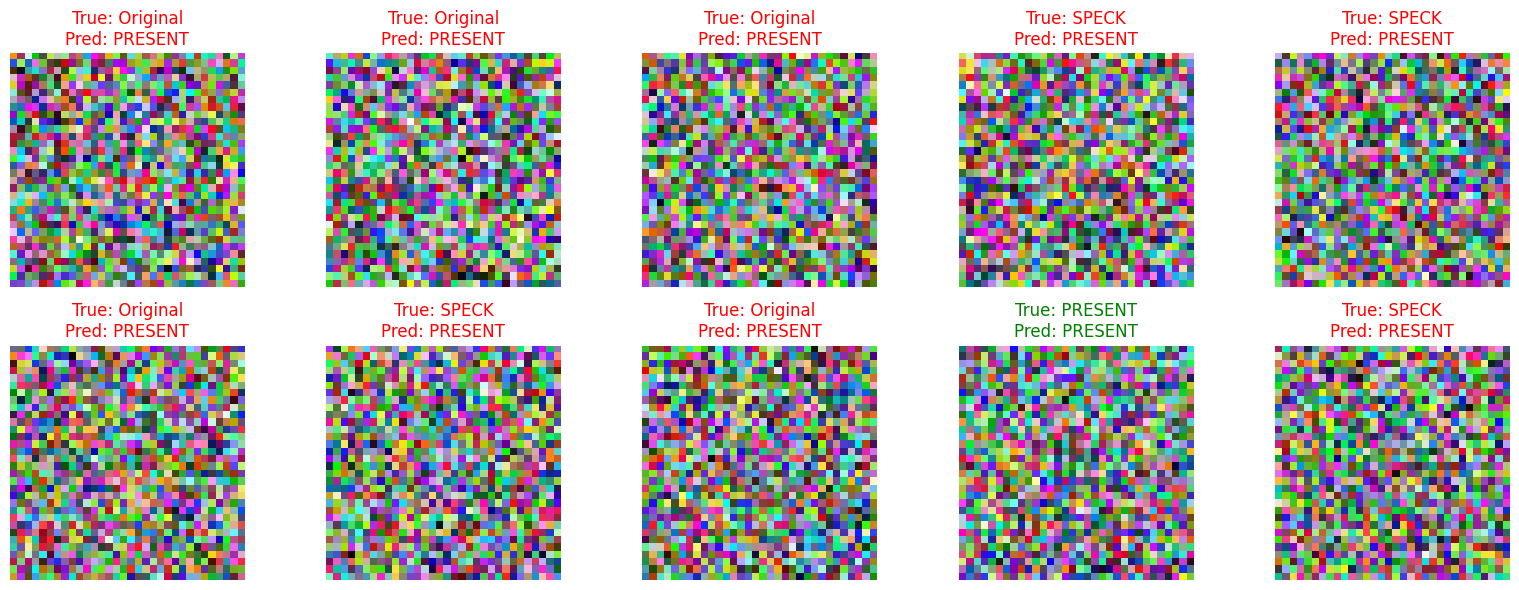


Demonstration complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import random

print("Generating dummy data for demonstration...")

img_height, img_width, img_channels = 32, 32, 3
num_classes = 3
num_train_samples = 108000
X_train = np.random.rand(num_train_samples, img_height, img_width, img_channels).astype(np.float32)
y_train_labels = np.random.randint(0, num_classes, num_train_samples)
y_train = tf.keras.utils.to_categorical(y_train_labels, num_classes=num_classes)

num_val_samples = 27000
X_val = np.random.rand(num_val_samples, img_height, img_width, img_channels).astype(np.float32)
y_val_labels = np.random.randint(0, num_classes, num_val_samples)
y_val = tf.keras.utils.to_categorical(y_val_labels, num_classes=num_classes)

num_test_samples = 15000
X_test = np.random.rand(num_test_samples, img_height, img_width, img_channels).astype(np.float32)
y_test_labels = np.random.randint(0, num_classes, num_test_samples)
y_test_cat = tf.keras.utils.to_categorical(y_test_labels, num_classes=num_classes)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test_cat shape: {y_test_cat.shape}")


print("\nDefining a simple placeholder Keras model...")
model = Sequential([
    Flatten(input_shape=(img_height, img_width, img_channels)),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


print("\nStarting model training...")

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

print("\nEvaluating the model...")
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

print("\nPlotting accuracy and loss...")
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("\nGenerating Confusion Matrix and Classification Report...")
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

labels = ['Original', 'SPECK', 'PRESENT']
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=labels))

print("\nVisualizing random predictions...")
plt.figure(figsize=(16, 6))
for i in range(10):
    idx = random.randint(0, len(X_test) - 1)
    img = X_test[idx]
    true_label = y_true[idx]
    pred_label = y_pred_classes[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {labels[true_label]}\nPred: {labels[pred_label]}",
              color="green" if true_label == pred_label else "red")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("\nDemonstration complete.")


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

if 'X_train' in locals() and 'y_train' in locals():
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        batch_size=128,
                        epochs=30,
                        callbacks=[early_stopping])
else:
    print("Training data not found. Please run the previous cells to load and prepare the data.")

In [ ]:

if 'X_test' in locals() and 'y_test_cat' in locals():
    test_loss, test_acc = model.evaluate(X_test, y_test_cat)
    print(f"Test Accuracy: {test_acc:.4f}")

    with open("test_accuracy.txt", "w") as f:
        f.write(f"Test Accuracy: {test_acc:.4f}\n")
else:
     print("Test data not found. Please run the previous cells to load and prepare the data.")

In [ ]:
import matplotlib.pyplot as plt

if 'history' in locals():
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig('accuracy_plot.png')
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('loss_plot.png')
    plt.show()
else:
    print("Model training history not found. Please run the training cell.")

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

if 'model' in locals() and 'X_test' in locals() and 'y_test_cat' in locals():
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Original", "SPECK", "PRESENT"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.savefig("confusion_matrix.png")
    plt.show()

    report = classification_report(y_true, y_pred, target_names=["Original", "SPECK", "PRESENT"])
    with open("classification_report.txt", "w") as f:
        f.write(report)
    print("\nClassification Report:")
    print(report)
else:
    print("Model or test data not found. Please run previous cells.")

In [ ]:
import shutil
import os
from google.colab import files

if 'model' in locals():
    model.save("encryption_classifier.keras")
    print("Model saved locally as encryption_classifier.keras")


    print("Attempting to download files...")
    files_to_download = ["encryption_classifier.keras", "accuracy_plot.png", "loss_plot.png",
                             "confusion_matrix.png", "classification_report.txt", "test_accuracy.txt"]
    for file_to_download in files_to_download:
        try:
            files.download(file_to_download)
            print(f"Initiated download for {file_to_download}")
        except FileNotFoundError:
            print(f"Could not find {file_to_download} locally to download.")
else:
    print("Model not found. Please run the model building and training cells.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

if 'model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    class_names = ['Original', 'SPECK', 'PRESENT']
    y_pred_probs = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    plt.figure(figsize=(18, 6))
    for i in range(10):
        idx = random.randint(0, len(X_test) - 1)
        img = X_test[idx]
        true_label = int(y_test[idx])
        pred_label = int(y_pred_classes[idx])
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
                  color="green" if true_label == pred_label else "red")
        plt.axis('off')
    plt.tight_layout()

    plt.savefig(os.path.join("/content/", "sample_predictions.png"))
    plt.show()
else:
    print("Model or test data not found. Please run previous cells.")